In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions
from numba import njit

In [36]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *,bathymetry:np.ndarray, h_initial: np.ndarray, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        self.bathymetry = bathymetry
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']- self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output

In [37]:
#@njit
def generate_openpit_bathymetry(
    L=500, W=500, H_max=38,
    terrace_depths=[7, 14, 21, 28, 35],
    nx=250, ny=250,
    min_terrace_width=60,   # szerokość najwyższego (najpłytszego) tarasu w metrach (po 30 m z każdej strony)
    H_wzb=10, sigma_x=5, sigma_y=5,
):
    """
    Generuje batymetrię zalanej kopalni odkrywkowej z tarasami i wizualizuje warunki początkowe.
    
    Parametry:
    -----------
    L, W           : wymiary zbiornika (m)
    H_max          : maksymalna głębokość (m)
    terrace_depths : lista głębokości kolejnych tarasów (od najgłębszego do najwyższego)
    nx, ny         : liczba punktów siatki w kierunkach x i y
    min_terrace_width : całkowita szerokość najwyższego tarasu (60 m = 30 m od brzegu z każdej strony)
    H_wzb          : amplituda początkowego wzbudzenia Gaussa na powierzchni wody (m)
    sigma_x, sigma_y : szerokości Gaussa wzbudzenia
    plot           : czy wyświetlić wizualizację 3D
    
    Zwraca:
    -------
    X, Y, Z_dna, water_surface
    """
    
    # === Siatka ===
    x = np.linspace(-L/2, L/2, nx)
    y = np.linspace(-W/2, W/2, ny)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    # === Budowa tarasów z pionowymi ścianami ===
    half_min_width = min_terrace_width / 2  # 30 m od brzegu

    for depth in terrace_depths:
        fraction = depth / H_max
        
        # Odległość od brzegu dla bieżącego tarasu (im głębszy → mniejsza)
        offset_x = half_min_width + (L/2 - min_terrace_width) * (1 - fraction)
        offset_y = half_min_width + (W/2 - min_terrace_width) * (1 - fraction)
        
        # Obszar wewnętrzny (głębszy niż bieżący taras) – zostaje bez zmian
        inner_mask = (np.abs(X) < L/2 - offset_x) & (np.abs(Y) < W/2 - offset_y)
        
        # Poza tym obszarem – ustawiamy bieżącą głębokość
        Z = np.where(inner_mask, Z, depth)

    # === Lustro wody + wzbudzenie Gaussa ===
    water = np.full_like(X, H_max)
    disturbance = H_wzb * np.exp(-(X**2/(2*sigma_x**2) + Y**2/(2*sigma_y**2)))
    water += disturbance

    return X, Y, Z, water

### Opis modelu fizycznego i warunków początkowych

Model przedstawia uproszczoną geometrię zalanej kopalni odkrywkowej o wymiarach  
**500 × 500 m** i maksymalnej głębokości  
**Hₘₐₓ = 38 m**.

Dno zbiornika zbudowano jako układ pięciu płaskich, poziomych tarasów o głębokościach od dna:

**7 m, 14 m, 21 m, 28 m, 35 m**

(gdzie największa wartość odpowiada najwyżej położonemu tarasowi, najbliższemu brzegom).

Tarasy oddzielone są pionowymi ścianami. Zasięg każdego tarasu w kierunkach **x** i **y** zależy liniowo od względnej głębokości **d/Hₘₐₓ** – im głębszy poziom, tym węższy (leży bliżej środka zbiornika), natomiast płytsze tarasy są szersze i sięgają bliżej krawędzi. Dzięki temu batymetria wiernie odwzorowuje typowy stożkowy profil wyrobiska odkrywkowego.

Siatka obliczeniowa ma rozdzielczość **250 × 250 punktów** (krok co 2 m).

Lustro wody w stanie spoczynku znajduje się na stałym poziomie równym maksymalnej głębokości:

**zₚₒₜ(x,y) = Hₘₐₓ = 38 m**

Na powierzchnię wody nałożono początkowe zaburzenie w postaci dwuwymiarowej funkcji Gaussa:

Δh(x,y) = H₍wzb₎ ⋅ exp(− x²/(2σₓ²) − y²/(2σᵧ²) ) 
gdzie:  
- **H₍wzb₎ = 10 m** – amplituda wzbudzenia  
- **σₓ = σᵧ = 5 m** – szerokości rozkładu Gaussa  

Zaburzenie to symuluje silny, lokalny impuls (np. zsuwisko materiału, uderzenie ufo w taflę wody) i stanowi warunek początkowy do analizy propagacji fal powierzchniowych w zbiorniku o złożonej, tarasowej batymetrii.

Model umożliwia badanie wpływu niejednorodnej głębokości (tarasów) na prędkość, odbicia i zniekształcenia rozchodzących się fal oraz ocenę potencjalnych zagrożeń w rzeczywistych zalanych odkrywkach.

C:\Users\karol\AppData\Local\Temp\ipykernel_11144\745853475.py:24: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 7 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(surf, shrink=0.6, aspect=20, pad=0.1)


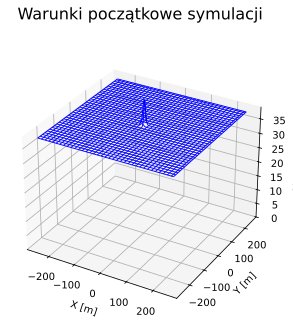

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# ==================== PARAMETRY ====================

X,Y,Z,water = generate_openpit_bathymetry()
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap=cm.terrain, linewidth=0,
                               antialiased=True, alpha=0.95, rstride=1, cstride=1)
ax.plot_wireframe(X, Y, water,
                  color='blue', linewidth=0.9,rstride=7, cstride=7)

# Osie i tytuł
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Głębokość [m]')
ax.set_zlim(0,H_max+1)
ax.set_title('Warunki początkowe symulacji', 
             fontsize=16, pad=30)

# Kolorbar
cbar = fig.colorbar(surf, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Wysokość od dna [m]', rotation=270, labelpad=20)



show_plot()

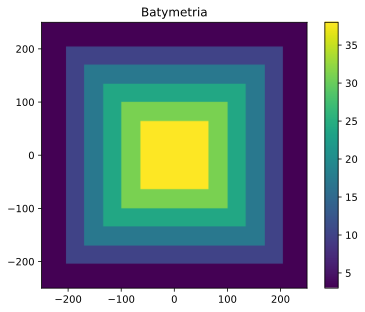

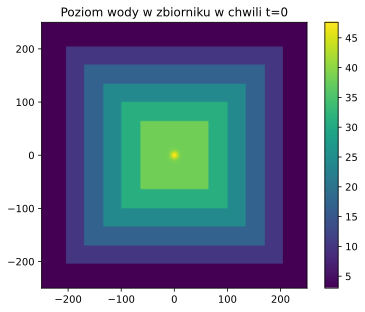

In [43]:
h = water - Z 
bathymetry = np.full_like(X,H_max) - Z
plt.imshow(bathymetry, extent=[-L/2, L/2, -W/2, W/2], cmap='viridis')
plt.title("Batymetria")
plt.colorbar()
plt.show()
plt.imshow(h, extent=[-L/2, L/2, -W/2, W/2], cmap='viridis')
plt.title("Poziom wody w zbiorniku w chwili t=0")
plt.colorbar()
plt.show()

Simulation